# ANALISI SU DATAFRAME A LIVELLO COMUNALE CON DF AGGREGATO DAL 2001 AL 2024

L'analisi temporale ha evidenziato un trend decrescente degli incidenti nel periodo 2001-2024. Tuttavia, questa analisi non considera le differenze strutturali tra i comuni. Per questo motivo, nel notebook successivo viene effettuata un'analisi a livello comunale, aggregando gli incidenti sull'intero periodo (2001-2024) e studiando come caratteristiche demografiche e territoriali influenzino l'incidentalità.

# LIBRERIE

In [285]:
import pandas as pd
import os

#grafici
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

# ANALISI ESPLORATIVA INTRO 

Carico i tre df, quello totale, quello solo degli incidenti, quello dei feriti e quello dei morti. Tutti questi presentano registrazioni dall' anno 2001 al 2024

In [286]:
os.getcwd()

'c:\\Users\\eliav\\Desktop\\Road_accidents_analysis\\Road_accidents_analysis_FIXED'

In [287]:
os.listdir()

['00_FIXED_fetching.ipynb',
 '01_FIXED_cleanind_overview.ipynb',
 '02a.EDA_&_Temporal_analysis.ipynb',
 '02b_EDA_Municipality_analysis_aggregate_01_24.ipynb',
 '02_FIXED_EDA.ipynb',
 'Df_clean',
 'Df_raw',
 'FIXED_fetching data']

In [288]:
df_total= pd.read_csv ("Df_clean/df_final_from_01_to_24_clean.csv")
df_total

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI
0,1001,morti_e_feriti,feriti,2001,10,1,1,Agliè,0,0,13.1462,2557
1,1001,morti_e_feriti,feriti,2002,10,1,1,Agliè,0,0,13.1462,2538
2,1001,morti_e_feriti,feriti,2003,7,1,1,Agliè,0,0,13.1462,2588
3,1001,morti_e_feriti,feriti,2004,13,1,1,Agliè,0,0,13.1462,2679
4,1001,morti_e_feriti,feriti,2005,2,1,1,Agliè,0,0,13.1462,2674
...,...,...,...,...,...,...,...,...,...,...,...,...
572695,111107,incidenti_stradali,incidenti,2020,2,20,111,Villaspeciosa,0,0,27.1937,2549
572696,111107,incidenti_stradali,incidenti,2021,5,20,111,Villaspeciosa,0,0,27.1943,2536
572697,111107,incidenti_stradali,incidenti,2022,1,20,111,Villaspeciosa,0,0,27.1943,2575
572698,111107,incidenti_stradali,incidenti,2023,4,20,111,Villaspeciosa,0,0,27.1943,2616


In [289]:
df_accidents= pd.read_csv ("Df_clean/df_incidenti_from_01_to_24.csv")
df_accidents

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI
0,1001,incidenti_stradali,incidenti,2001,5,1,1,Agliè,0,0,13.1462,2557
1,1001,incidenti_stradali,incidenti,2002,5,1,1,Agliè,0,0,13.1462,2538
2,1001,incidenti_stradali,incidenti,2003,4,1,1,Agliè,0,0,13.1462,2588
3,1001,incidenti_stradali,incidenti,2004,9,1,1,Agliè,0,0,13.1462,2679
4,1001,incidenti_stradali,incidenti,2005,2,1,1,Agliè,0,0,13.1462,2674
...,...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,incidenti_stradali,incidenti,2020,2,20,111,Villaspeciosa,0,0,27.1937,2549
190896,111107,incidenti_stradali,incidenti,2021,5,20,111,Villaspeciosa,0,0,27.1943,2536
190897,111107,incidenti_stradali,incidenti,2022,1,20,111,Villaspeciosa,0,0,27.1943,2575
190898,111107,incidenti_stradali,incidenti,2023,4,20,111,Villaspeciosa,0,0,27.1943,2616


In [290]:
df_wounded= pd.read_csv ("Df_clean/df_feriti_from_01_to_24.csv")
df_wounded

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI
0,1001,morti_e_feriti,feriti,2001,10,1,1,Agliè,0,0,13.1462,2557
1,1001,morti_e_feriti,feriti,2002,10,1,1,Agliè,0,0,13.1462,2538
2,1001,morti_e_feriti,feriti,2003,7,1,1,Agliè,0,0,13.1462,2588
3,1001,morti_e_feriti,feriti,2004,13,1,1,Agliè,0,0,13.1462,2679
4,1001,morti_e_feriti,feriti,2005,2,1,1,Agliè,0,0,13.1462,2674
...,...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,morti_e_feriti,feriti,2020,3,20,111,Villaspeciosa,0,0,27.1937,2549
190896,111107,morti_e_feriti,feriti,2021,7,20,111,Villaspeciosa,0,0,27.1943,2536
190897,111107,morti_e_feriti,feriti,2022,1,20,111,Villaspeciosa,0,0,27.1943,2575
190898,111107,morti_e_feriti,feriti,2023,5,20,111,Villaspeciosa,0,0,27.1943,2616


In [291]:
df_deaths= pd.read_csv ("Df_clean/df_morti_from_01_to_24.csv")
df_deaths

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI
0,1001,morti_e_feriti,morti,2001,0,1,1,Agliè,0,0,13.1462,2557
1,1001,morti_e_feriti,morti,2002,0,1,1,Agliè,0,0,13.1462,2538
2,1001,morti_e_feriti,morti,2003,0,1,1,Agliè,0,0,13.1462,2588
3,1001,morti_e_feriti,morti,2004,0,1,1,Agliè,0,0,13.1462,2679
4,1001,morti_e_feriti,morti,2005,0,1,1,Agliè,0,0,13.1462,2674
...,...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,morti_e_feriti,morti,2020,0,20,111,Villaspeciosa,0,0,27.1937,2549
190896,111107,morti_e_feriti,morti,2021,0,20,111,Villaspeciosa,0,0,27.1943,2536
190897,111107,morti_e_feriti,morti,2022,0,20,111,Villaspeciosa,0,0,27.1943,2575
190898,111107,morti_e_feriti,morti,2023,0,20,111,Villaspeciosa,0,0,27.1943,2616


# EDA

## FEATURE ENGINEERING: RAGGRUPPO INCIDENTI/FERITI/MORTI PER COMUNE aggregando gli anni dal 01 al 24 e creazioni colonne densità e incidenti pro capite

In [292]:
# df_accidents_municipality= (df_accidents.groupby(["ID_COMUNE", "COMUNE"], as_index=False).agg({"OBS_VALUE": "sum",
#                                                                                                                "RESIDENTI": "mean",
#                                                                                                                "SUPERFICIE (KMQ)": "mean",
#                                                                                                                "ID_REGIONE":"mean"}))

# df_accidents_municipality["DENSITA_POPOLAZIONE"] = (df_accidents_municipality["RESIDENTI"]/ df_accidents_municipality["SUPERFICIE (KMQ)"])
# df_accidents_municipality["DENSITA_INCIDENTI"] = (df_accidents_municipality["OBS_VALUE"]/ df_accidents_municipality["SUPERFICIE (KMQ)"])
# df_accidents_municipality["INCIDENTI_PRO_CAPITE(1000)"] = (df_accidents_municipality["OBS_VALUE"]/ df_accidents_municipality["RESIDENTI"]) * 1000


In [293]:
def create_municipality_dataset(df, value_col="OBS_VALUE", value_name="INCIDENTI"): #i nomi delle colonne nei parametri vengono utilizzati solo e unicamente
                                                                                    #se non se ne passa uno differente

    df_municipality = (df.groupby(["ID_COMUNE", "COMUNE"], as_index=False).agg({value_col: "sum",
                                                                                "RESIDENTI": "mean",
                                                                                "SUPERFICIE (KMQ)": "mean",
                                                                                "ID_REGIONE": "mean"}))

    df_municipality["DENSITA_POPOLAZIONE"] = (df_municipality["RESIDENTI"] /df_municipality["SUPERFICIE (KMQ)"])

    df_municipality[f"DENSITA_{value_name}"] = (df_municipality[value_col] /df_municipality["SUPERFICIE (KMQ)"])

    df_municipality[f"{value_name}_PRO_CAPITE(1000)"] = (df_municipality[value_col] /df_municipality["RESIDENTI"]) * 1000

    return df_municipality

In [294]:
df_accidents_municipality = create_municipality_dataset(df_accidents,value_name="INCIDENTI")

In [295]:
df_wounded_municipality = create_municipality_dataset(df_wounded,value_name="FERITI")

In [296]:
df_deaths_municipality = create_municipality_dataset(df_deaths,value_name="MORTI")

## DATA OVERVIEW e CLEANING CHECK

Prima di iniziare con l' analisi esplorativa ricontrollo la pulizia dei dati del mio df

In [297]:
df_accidents_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_COMUNE                   8614 non-null   int64  
 1   COMUNE                      8614 non-null   str    
 2   OBS_VALUE                   8614 non-null   int64  
 3   RESIDENTI                   8614 non-null   float64
 4   SUPERFICIE (KMQ)            8614 non-null   float64
 5   ID_REGIONE                  8614 non-null   float64
 6   DENSITA_POPOLAZIONE         8614 non-null   float64
 7   DENSITA_INCIDENTI           8614 non-null   float64
 8   INCIDENTI_PRO_CAPITE(1000)  8614 non-null   float64
dtypes: float64(6), int64(2), str(1)
memory usage: 605.8 KB


In [298]:
df_wounded_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_COMUNE                8614 non-null   int64  
 1   COMUNE                   8614 non-null   str    
 2   OBS_VALUE                8614 non-null   int64  
 3   RESIDENTI                8614 non-null   float64
 4   SUPERFICIE (KMQ)         8614 non-null   float64
 5   ID_REGIONE               8614 non-null   float64
 6   DENSITA_POPOLAZIONE      8614 non-null   float64
 7   DENSITA_FERITI           8614 non-null   float64
 8   FERITI_PRO_CAPITE(1000)  8614 non-null   float64
dtypes: float64(6), int64(2), str(1)
memory usage: 605.8 KB


In [299]:
df_deaths_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_COMUNE               8614 non-null   int64  
 1   COMUNE                  8614 non-null   str    
 2   OBS_VALUE               8614 non-null   int64  
 3   RESIDENTI               8614 non-null   float64
 4   SUPERFICIE (KMQ)        8614 non-null   float64
 5   ID_REGIONE              8614 non-null   float64
 6   DENSITA_POPOLAZIONE     8614 non-null   float64
 7   DENSITA_MORTI           8614 non-null   float64
 8   MORTI_PRO_CAPITE(1000)  8614 non-null   float64
dtypes: float64(6), int64(2), str(1)
memory usage: 605.8 KB


In [300]:
def change_type_col_Int64 (df, col):
    df[col] = (df[col].astype("int64"))

In [301]:
change_type_col_Int64(df_accidents_municipality,"ID_REGIONE")
change_type_col_Int64(df_wounded_municipality,"ID_REGIONE")
change_type_col_Int64(df_deaths_municipality,"ID_REGIONE")

In [302]:
def check_df (df):
    print(df.info())
    print("-"*40)
    print("Dati duplicati:",df.duplicated().sum())
    print("-"*40)
    print("Dati nulli: \n", df.isna().sum())
    print("-"*40)
    return df.head()

In [303]:
check_df (df_accidents_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_COMUNE                   8614 non-null   int64  
 1   COMUNE                      8614 non-null   str    
 2   OBS_VALUE                   8614 non-null   int64  
 3   RESIDENTI                   8614 non-null   float64
 4   SUPERFICIE (KMQ)            8614 non-null   float64
 5   ID_REGIONE                  8614 non-null   int64  
 6   DENSITA_POPOLAZIONE         8614 non-null   float64
 7   DENSITA_INCIDENTI           8614 non-null   float64
 8   INCIDENTI_PRO_CAPITE(1000)  8614 non-null   float64
dtypes: float64(5), int64(3), str(1)
memory usage: 605.8 KB
None
----------------------------------------
Dati duplicati: 0
----------------------------------------
Dati nulli: 
 ID_COMUNE                     0
COMUNE                        0
OBS_VALUE                     0
RES

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000)
0,1001,Agliè,95,2630.541667,13.146217,1,200.098761,7.226414,36.114235
1,1002,Airasca,262,3699.041667,15.739300,1,235.019452,16.646230,70.829156
2,1003,Ala di Stura,6,463.875000,46.331517,1,10.012083,0.129501,12.934519
3,1004,Albiano d'Ivrea,107,1696.000000,11.732788,1,144.552179,9.119742,63.089623
4,1005,Alice Superiore,21,687.222222,7.379600,1,93.124590,2.845683,30.557801


In [304]:
check_df (df_wounded_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_COMUNE                8614 non-null   int64  
 1   COMUNE                   8614 non-null   str    
 2   OBS_VALUE                8614 non-null   int64  
 3   RESIDENTI                8614 non-null   float64
 4   SUPERFICIE (KMQ)         8614 non-null   float64
 5   ID_REGIONE               8614 non-null   int64  
 6   DENSITA_POPOLAZIONE      8614 non-null   float64
 7   DENSITA_FERITI           8614 non-null   float64
 8   FERITI_PRO_CAPITE(1000)  8614 non-null   float64
dtypes: float64(5), int64(3), str(1)
memory usage: 605.8 KB
None
----------------------------------------
Dati duplicati: 0
----------------------------------------
Dati nulli: 
 ID_COMUNE                  0
COMUNE                     0
OBS_VALUE                  0
RESIDENTI                  0
SUPERFICIE (KMQ)

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_FERITI,FERITI_PRO_CAPITE(1000)
0,1001,Agliè,161,2630.541667,13.146217,1,200.098761,12.246870,61.204125
1,1002,Airasca,427,3699.041667,15.739300,1,235.019452,27.129542,115.435304
2,1003,Ala di Stura,10,463.875000,46.331517,1,10.012083,0.215836,21.557532
3,1004,Albiano d'Ivrea,165,1696.000000,11.732788,1,144.552179,14.063154,97.287736
4,1005,Alice Superiore,34,687.222222,7.379600,1,93.124590,4.607296,49.474535


In [305]:
check_df (df_deaths_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_COMUNE               8614 non-null   int64  
 1   COMUNE                  8614 non-null   str    
 2   OBS_VALUE               8614 non-null   int64  
 3   RESIDENTI               8614 non-null   float64
 4   SUPERFICIE (KMQ)        8614 non-null   float64
 5   ID_REGIONE              8614 non-null   int64  
 6   DENSITA_POPOLAZIONE     8614 non-null   float64
 7   DENSITA_MORTI           8614 non-null   float64
 8   MORTI_PRO_CAPITE(1000)  8614 non-null   float64
dtypes: float64(5), int64(3), str(1)
memory usage: 605.8 KB
None
----------------------------------------
Dati duplicati: 0
----------------------------------------
Dati nulli: 
 ID_COMUNE                 0
COMUNE                    0
OBS_VALUE                 0
RESIDENTI                 0
SUPERFICIE (KMQ)          0
ID_

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_MORTI,MORTI_PRO_CAPITE(1000)
0,1001,Agliè,1,2630.541667,13.146217,1,200.098761,0.076068,0.380150
1,1002,Airasca,8,3699.041667,15.739300,1,235.019452,0.508282,2.162722
2,1003,Ala di Stura,0,463.875000,46.331517,1,10.012083,0.000000,0.000000
3,1004,Albiano d'Ivrea,10,1696.000000,11.732788,1,144.552179,0.852312,5.896226
4,1005,Alice Superiore,5,687.222222,7.379600,1,93.124590,0.677543,7.275667


# STATISTICA DESCRITTIVA

Voglio capire la distribuzione dei dati e vedere se ci sono punti di analisi interessanti

In [306]:
print("---- Incidenti ----")
display(df_accidents_municipality[["OBS_VALUE","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_INCIDENTI","INCIDENTI_PRO_CAPITE(1000)"]].describe())

print("---- Feriti ----")
display(df_wounded_municipality[["OBS_VALUE","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_FERITI","FERITI_PRO_CAPITE(1000)"]].describe())

print("---- Morti ----")
display(df_deaths_municipality[["OBS_VALUE","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_MORTI","MORTI_PRO_CAPITE(1000)"]].describe())

---- Incidenti ----


,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000)
count,8614.000000,8.614000e+03,8614.000000,8614.000000,8614.000000,8614.000000
mean,554.092640,7.230314e+03,38.321339,294.240836,15.788135,43.981087
std,5734.537761,3.950179e+04,50.713202,633.316850,43.877241,38.688927
min,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,21.000000,1.027006e+03,11.330942,44.207819,0.893272,17.392787
50%,78.000000,2.418562e+03,22.349802,102.624523,3.511598,34.647726
75%,258.000000,6.021292e+03,44.802008,264.942062,12.653336,59.382154
max,390605.000000,2.693100e+06,1287.499925,12215.874974,1499.948783,556.658679


---- Feriti ----


,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_FERITI,FERITI_PRO_CAPITE(1000)
count,8614.000000,8.614000e+03,8614.000000,8614.000000,8614.000000,8614.000000
mean,777.787671,7.230314e+03,38.321339,294.240836,22.370969,65.469374
std,7507.108557,3.950179e+04,50.713202,633.316850,58.867727,59.014295
min,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,32.000000,1.027006e+03,11.330942,44.207819,1.319865,25.488032
50%,118.000000,2.418562e+03,22.349802,102.624523,5.295229,51.693894
75%,387.750000,6.021292e+03,44.802008,264.942062,19.174629,88.158313
max,506345.000000,2.693100e+06,1287.499925,12215.874974,1959.154516,893.529613


---- Morti ----


,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_MORTI,MORTI_PRO_CAPITE(1000)
count,8614.000000,8.614000e+03,8614.000000,8614.000000,8614.000000,8614.000000
mean,11.819596,7.230314e+03,38.321339,294.240836,0.389732,2.044354
std,58.211738,3.950179e+04,50.713202,633.316850,0.611371,2.778442
min,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,1.000000,1.027006e+03,11.330942,44.207819,0.037892,0.570206
50%,4.000000,2.418562e+03,22.349802,102.624523,0.170581,1.459437
75%,11.000000,6.021292e+03,44.802008,264.942062,0.494214,2.629562
max,4350.000000,2.693100e+06,1287.499925,12215.874974,7.897509,73.482428


# CLASSIFICHE

-COMUNE CON PIù INCIDENTI/ FERITI/ MORTI: Roma sia per incidenti che per morti e feriti
-REGIONE CON PIù INCIDENTI/ FERITI/ MORTI: 

In [307]:
#COMUNE CON PIù INCIDENTI
display(df_accidents_municipality.loc[df_accidents_municipality["OBS_VALUE"].idxmax()]) # modo 1 -per trovare il valore più alto di incidenti
#COMUNE CON PIù FERITI
display(df_wounded_municipality.sort_values("OBS_VALUE", ascending=False).head(1)) # modo 2 -per trovare il valore più alto di feriti
#COMUNE CON PIù MORTI
display(df_deaths_municipality.sort_values("OBS_VALUE", ascending=False).head(1))

ID_COMUNE                              58091
COMUNE                                  Roma
OBS_VALUE                             390605
RESIDENTI                     2693099.666667
SUPERFICIE (KMQ)                 1287.499925
ID_REGIONE                                12
DENSITA_POPOLAZIONE              2091.728018
DENSITA_INCIDENTI                 303.382542
INCIDENTI_PRO_CAPITE(1000)        145.039192
Name: 5148, dtype: object

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_FERITI,FERITI_PRO_CAPITE(1000)
5148,58091,Roma,506345,2.693100e+06,1287.499925,12,2091.728018,393.277693,188.015693


,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_MORTI,MORTI_PRO_CAPITE(1000)
5148,58091,Roma,4350,2.693100e+06,1287.499925,12,2091.728018,3.378641,1.615239


In [ ]:
df_region_accidents=df_accidents_municipality.groupby("ID_REGIONE", as_index=False)["OBS_VALUE"].sum() #devo mettere as_index=false per far si che non esca una serie con indice l'id regionale

regioni = {
    1: "Piemonte",
    2: "Valle d'Aosta",
    3: "Lombardia",
    4: "Trentino-Alto Adige",
    5: "Veneto",
    6: "Friuli-Venezia Giulia",
    7: "Liguria",
    8: "Emilia-Romagna",
    9: "Toscana",
    10: "Umbria",
    11: "Marche",
    12: "Lazio",
    13: "Abruzzo",
    14: "Molise",
    15: "Campania",
    16: "Puglia",
    17: "Basilicata",
    18: "Calabria",
    19: "Sicilia",
    20: "Sardegna"
}

df_region_accidents["REGIONE"] = df_region_accidents["ID_REGIONE"].map(regioni)
df_region_accidents.sort_values("OBS_VALUE", ascending=False).head()

# CORR

In [ ]:
corr_accidents=df_accidents_municipality [["OBS_VALUE","ID_REGIONE","SUPERFICIE (KMQ)","RESIDENTI", "INCIDENTI_PRO_CAPITE(1000)","DENSITA_INCIDENTI","DENSITA_POPOLAZIONE"]].corr()

corr_accidents

,OBS_VALUE,ID_REGIONE,SUPERFICIE (KMQ),RESIDENTI,INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI,DENSITA_POPOLAZIONE
OBS_VALUE,1.000000,0.002271,0.321485,0.958595,0.162306,0.468321,0.212585
ID_REGIONE,0.002271,1.000000,0.271262,0.031001,-0.248823,-0.090460,-0.055167
SUPERFICIE (KMQ),0.321485,0.271262,1.000000,0.371919,0.081830,-0.022891,-0.125970
RESIDENTI,0.958595,0.031001,0.371919,1.000000,0.154502,0.473654,0.285340
INCIDENTI_PRO_CAPITE(1000),0.162306,-0.248823,0.081830,0.154502,1.000000,0.348228,0.116211
DENSITA_INCIDENTI,0.468321,-0.090460,-0.022891,0.473654,0.348228,1.000000,0.763397
DENSITA_POPOLAZIONE,0.212585,-0.055167,-0.125970,0.285340,0.116211,0.763397,1.000000


In [ ]:
df_accidents_municipality["RESIDENTI"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
#0.75     6115.25--> il 75% dei comuni ha meno di 6115 abitanti, dunque l' Italia è un Paese di piccoli comuni

0.01      125.079583
0.05      295.010870
0.10      487.600000
0.25     1027.006341
0.50     2418.562500
0.75     6021.291667
0.90    13632.101923
0.95    23498.406250
0.99    68325.172500
Name: RESIDENTI, dtype: float64

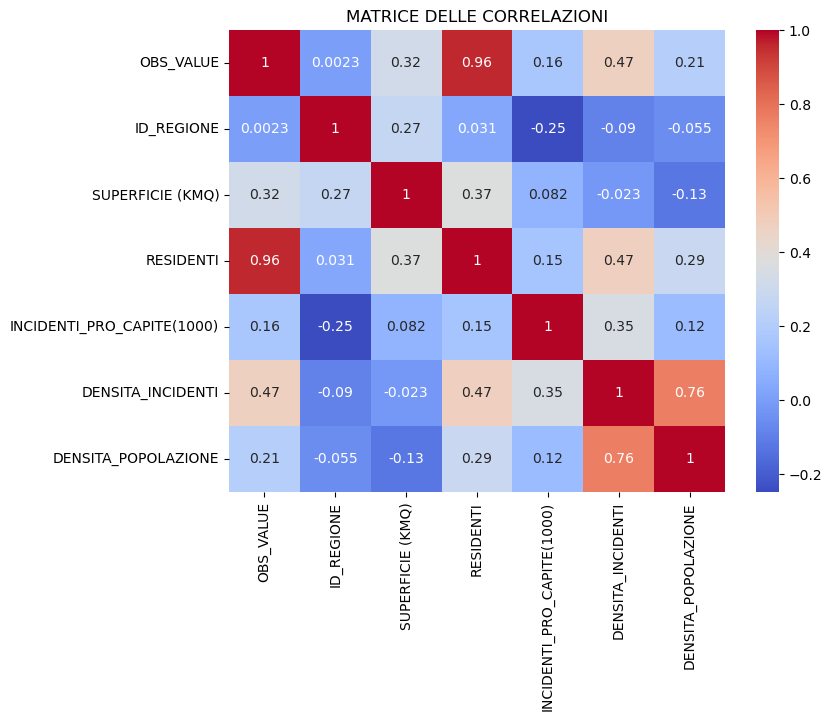

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_accidents,annot=True,cmap="coolwarm")

plt.title("MATRICE DELLE CORRELAZIONI")
plt.show()

Creo le colonne per la classificazione dei comuni in base alla superficie e alla demografia secondo la classificazione ufficiale:

-Classificazione Comuni per superficie -> https://www.istat.it/it/files/2015/04/Superfici-delle-unit%C3%A0-amministrative-Testo-integrale.pdf

-Classificazione comuni per classe demografica (da comprimere) ->https://finanzalocale.interno.gov.it/docum/studi/varie/200707varclass.html#due

In [ ]:
#ANDANDO AD ANALIZZARE I COMUNI, VOGLIO CAPIRE ANCHE QUALI SIANO LE DIFFERENZE
# TRA CLASSI DEMOGRAFICHE E QUELLE DI SUPERFICIE, DUNQUE LI CLASSIFICO IN COLONNE
df_accidents_municipality["CLASSE_DEMOGRAFICA"] = ""

for i in df_accidents_municipality.index:

    residenti = df_accidents_municipality.loc[i, "RESIDENTI"]

    if residenti < 1000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Molto piccolo"
    elif residenti < 5000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Piccolo"
    elif residenti < 20000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Medio"

    else:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Grande"


df_accidents_municipality["CLASSE_SUPERFICIE"] = ""

for i in df_accidents_municipality.index:

    superficie = df_accidents_municipality.loc[i, "SUPERFICIE (KMQ)"]

    if superficie < 10:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Molto piccolo"
    elif superficie < 50:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Piccolo"
    elif superficie < 100:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Medio"
    elif superficie < 250:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Grande"

    else:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Molto grande"

In [ ]:
print(df_accidents_municipality["CLASSE_DEMOGRAFICA"].value_counts())
print("--------------------------------------")
print(df_accidents_municipality["CLASSE_SUPERFICIE"].value_counts())

CLASSE_DEMOGRAFICA
Piccolo          3977
Molto piccolo    2106
Medio            2000
Grande            531
Name: count, dtype: int64
--------------------------------------
CLASSE_SUPERFICIE
Piccolo          4950
Molto piccolo    1811
Medio            1187
Grande            591
Molto grande       75
Name: count, dtype: int64


# CLASSIFICHE

In [ ]:
#COMUNE CON PIU' INCIDENTI TOTALI IN 24 ANNI
display(df_accidents_municipality.sort_values(by="OBS_VALUE",ascending=False).head(1))

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5148,58091,Roma,390605,2.693100e+06,1287.499925,12,2091.728018,303.382542,145.039192,Grande,Molto grande


In [ ]:
#COMUNE CON PIU' INCIDENTI PRO CAPITE TOTALI IN 24 ANNI
display(df_accidents_municipality.sort_values(by="INCIDENTI_PRO_CAPITE(1000)",ascending=False).head(1))

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
882,6014,Belforte Monferrato,271,486.833333,8.3258,1,58.472859,32.549425,556.658679,Molto piccolo,Molto piccolo


# SCATTERPLOT

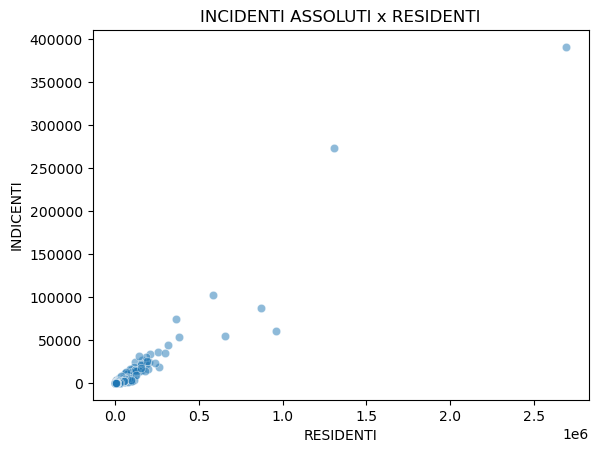

In [ ]:
sns.scatterplot(data=df_accidents_municipality,x="RESIDENTI",y="OBS_VALUE", alpha=0.5)
plt.title("INCIDENTI ASSOLUTI x RESIDENTI")
plt.ylabel("INDICENTI")
plt.show()

In [ ]:
df_accidents_municipality[df_accidents_municipality["OBS_VALUE"] >= 5000].sort_values("OBS_VALUE",ascending=False).head(10)

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5148,58091,Roma,390605,2.693100e+06,1287.499925,12,2091.728018,303.382542,145.039192,Grande,Molto grande
1875,15146,Milano,272545,1.310566e+06,181.702871,3,7212.689425,1499.948783,207.959707,Grande,Grande
1299,10025,Genova,102694,5.862910e+05,240.190217,7,2440.944375,427.552801,175.158765,Grande,Grande
271,1272,Torino,87227,8.728376e+05,130.021463,1,6713.027282,670.866166,99.934968,Grande,Grande
4631,48017,Firenze,74537,3.646007e+05,102.315325,9,3563.500466,728.502793,204.434600,Grande,Grande
5533,63049,Napoli,60731,9.588668e+05,118.998133,15,8057.830529,510.352543,63.336222,Grande,Grande
7047,82053,Palermo,54030,6.582088e+05,160.602017,19,4098.384609,336.421678,82.086410,Grande,Grande
4151,37006,Bologna,53858,3.799335e+05,140.856554,8,2697.307926,382.360624,141.756386,Grande,Grande
6315,72006,Bari,44172,3.173035e+05,117.424613,16,2702.188677,376.173266,139.210585,Grande,Grande
3269,23091,Verona,36503,2.566773e+05,198.910579,5,1290.415695,183.514623,142.213570,Grande,Grande


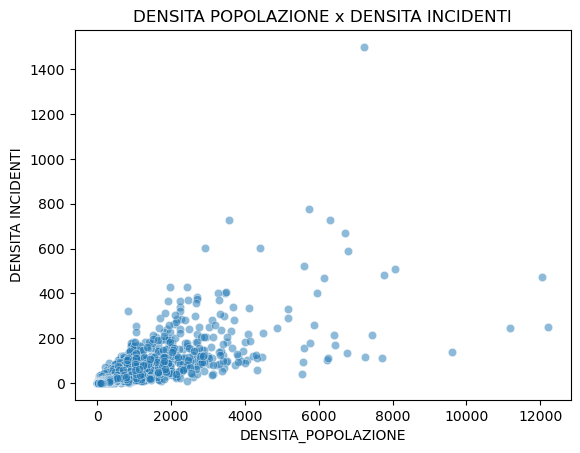

In [ ]:
sns.scatterplot(data=df_accidents_municipality,x="DENSITA_POPOLAZIONE",y="DENSITA_INCIDENTI", alpha=0.5)
plt.title("DENSITA POPOLAZIONE x DENSITA INCIDENTI")
plt.ylabel("DENSITA INCIDENTI")
plt.show()

In [ ]:
df_accidents_municipality[df_accidents_municipality["DENSITA_INCIDENTI"] >= 60]

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
7,1008,Alpignano,775,16915.166667,11.919300,1,1419.140945,65.020597,45.816870,Medio,Piccolo
23,1024,Beinasco,1218,18007.333333,6.734683,1,2673.820348,180.854829,67.639110,Medio,Molto piccolo
89,1090,Collegno,3919,48986.000000,18.100667,1,2706.309160,216.511362,80.002450,Grande,Piccolo
119,1120,Grugliasco,1929,37402.625000,13.132996,1,2847.988797,146.881947,51.573920,Grande,Piccolo
155,1156,Moncalieri,4004,55896.500000,47.531392,1,1175.991235,84.239065,71.632392,Grande,Piccolo
...,...,...,...,...,...,...,...,...,...,...,...
8450,108049,Villasanta,579,13931.066667,4.864793,3,2863.650254,119.018417,41.561785,Medio,Molto piccolo
8451,108050,Vimercate,1624,25825.000000,20.717840,3,1246.510254,78.386550,62.884802,Grande,Piccolo
8455,108054,Lentate sul Seveso,858,15753.666667,13.977727,3,1127.054996,61.383372,54.463511,Medio,Piccolo
8489,109033,Porto San Giorgio,877,15893.133333,8.808600,11,1804.274610,99.561792,55.181064,Medio,Molto piccolo


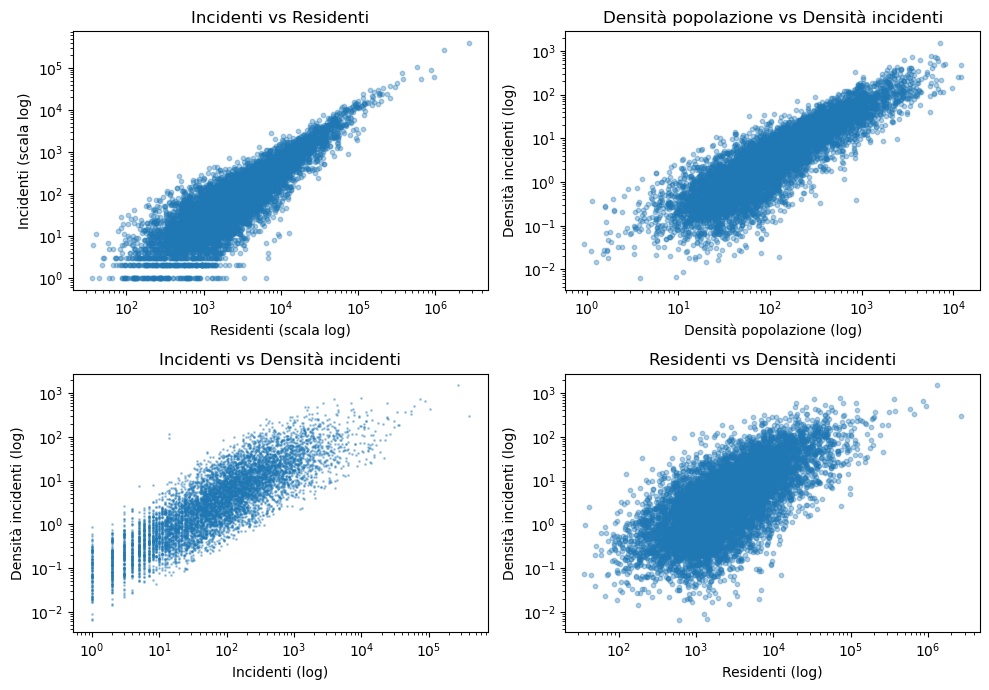

In [ ]:

fig, ax = plt.subplots(2, 2, figsize=(10,7))
# ==========================================================
# Incidenti vs Residenti
# ==========================================================
ax[0,0].scatter(
    df_accidents_municipality["RESIDENTI"],
    df_accidents_municipality["OBS_VALUE"],
    alpha=0.35,
    s=10)

ax[0,0].set_xscale("log")
ax[0,0].set_yscale("log")

ax[0,0].set_title("Incidenti vs Residenti")
ax[0,0].set_xlabel("Residenti (scala log)")
ax[0,0].set_ylabel("Incidenti (scala log)")

# ==========================================================
# Densità popolazione vs Densità incidenti
# ==========================================================
ax[0,1].scatter(
    df_accidents_municipality["DENSITA_POPOLAZIONE"],
    df_accidents_municipality["DENSITA_INCIDENTI"],
    alpha=0.35,
    s=10)

ax[0,1].set_xscale("log")
ax[0,1].set_yscale("log")

ax[0,1].set_title("Densità popolazione vs Densità incidenti")
ax[0,1].set_xlabel("Densità popolazione (log)")
ax[0,1].set_ylabel("Densità incidenti (log)")

# ==========================================================
# Incidenti vs Densità incidenti
# ==========================================================
ax[1,0].scatter(
    df_accidents_municipality["OBS_VALUE"],
    df_accidents_municipality["DENSITA_INCIDENTI"],
    alpha=0.35,
    s=1)

ax[1,0].set_xscale("log")
ax[1,0].set_yscale("log")

ax[1,0].set_title("Incidenti vs Densità incidenti")
ax[1,0].set_xlabel("Incidenti (log)")
ax[1,0].set_ylabel("Densità incidenti (log)")

# ==========================================================
# Residenti vs Densità incidenti
# ==========================================================
ax[1,1].scatter(
    df_accidents_municipality["RESIDENTI"],
    df_accidents_municipality["DENSITA_INCIDENTI"],
    alpha=0.35,
    s=10)

ax[1,1].set_xscale("log")
ax[1,1].set_yscale("log")

ax[1,1].set_title("Residenti vs Densità incidenti")
ax[1,1].set_xlabel("Residenti (log)")
ax[1,1].set_ylabel("Densità incidenti (log)")

plt.tight_layout()
plt.show()

# ANALISI OUTLIER SU DF INCIDENTI PER COMUNE (aggregato sui 24 anni)

In [ ]:
df_accidents_municipality["RESIDENTI"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.01      125.079583
0.05      295.010870
0.10      487.600000
0.25     1027.006341
0.50     2418.562500
0.75     6021.291667
0.90    13632.101923
0.95    23498.406250
0.99    68325.172500
Name: RESIDENTI, dtype: float64

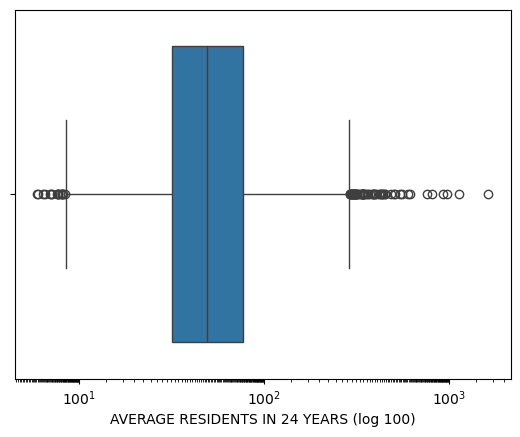

In [ ]:
sns.boxplot(data=df_accidents_municipality,x="RESIDENTI",log_scale=100)
plt.xlabel("AVERAGE RESIDENTS IN 24 YEARS (log 100)")
plt.show()

Noto che ci sono outlier per comuni sia piccoli che grandi. 

Ora gli analizzerò.

In [ ]:
col="RESIDENTI"

Q1 = df_accidents_municipality["RESIDENTI"].quantile(0.25)
Q3 = df_accidents_municipality["RESIDENTI"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_accidents_municipality[(df_accidents_municipality["RESIDENTI"] < lower) | (df_accidents_municipality["RESIDENTI"] > upper)]

print(outliers)

      ID_COMUNE                    COMUNE  OBS_VALUE     RESIDENTI  \
7          1008                 Alpignano        775  16915.166667   
23         1024                  Beinasco       1218  18007.333333   
58         1059                Carmagnola       1478  27717.125000   
62         1063          Caselle Torinese        872  16411.750000   
77         1078                    Chieri       1612  35512.125000   
...         ...                       ...        ...           ...   
8503     110007  San Ferdinando di Puglia        330  14223.933333   
8505     110009                     Trani       2225  55547.266667   
8506     110010               Trinitapoli        616  14315.866667   
8515     111009                  Carbonia        400  26576.875000   
8541     111035                  Iglesias        379  25517.125000   

      SUPERFICIE (KMQ)  ID_REGIONE  DENSITA_POPOLAZIONE  DENSITA_INCIDENTI  \
7            11.919300           1          1419.140945          65.020597   
23 

In [ ]:
#VOGLIO SAPERE QUANTI SONO
print(len(outliers))

866


In [ ]:
outliers.sort_values(by="RESIDENTI")

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
2334,17127,Ospitaletto,601,1.356088e+04,9.290192,3,1459.698087,64.691884,44.318674,Medio,Molto piccolo
1886,15159,Opera,963,1.361104e+04,7.634883,3,1782.743897,126.131593,70.751381,Medio,Molto piccolo
1928,15213,Solaro,1021,1.362700e+04,6.675996,3,2041.193605,152.935985,74.924782,Medio,Molto piccolo
6305,71060,Vieste,566,1.362875e+04,169.201963,16,80.547234,3.345115,41.529854,Medio,Grande
7430,90070,Tempio Pausania,348,1.363354e+04,210.817515,20,64.669856,1.650717,25.525288,Medio,Grande
...,...,...,...,...,...,...,...,...,...,...,...
7047,82053,Palermo,54030,6.582088e+05,160.602017,19,4098.384609,336.421678,82.086410,Grande,Grande
271,1272,Torino,87227,8.728376e+05,130.021463,1,6713.027282,670.866166,99.934968,Grande,Grande
5533,63049,Napoli,60731,9.588668e+05,118.998133,15,8057.830529,510.352543,63.336222,Grande,Grande
1875,15146,Milano,272545,1.310566e+06,181.702871,3,7212.689425,1499.948783,207.959707,Grande,Grande


In [ ]:
col = "DENSITA_INCIDENTI"

Q1 = df_accidents_municipality[col].quantile(0.25)
Q3 = df_accidents_municipality[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_accidents_municipality[(df_accidents_municipality[col] < lower) | (df_accidents_municipality[col] > upper)]

outliers[["COMUNE", col]].sort_values(col, ascending=False).head(10)

,COMUNE,DENSITA_INCIDENTI
1875,Milano,1499.948783
1827,Cinisello Balsamo,774.829883
4631,Firenze,728.502793
1838,Corsico,728.064514
271,Torino,670.866166
1834,Cormano,600.434790
1982,Bergamo,600.377976
1924,Sesto San Giovanni,590.803736
1830,Cologno Monzese,520.373921
5533,Napoli,510.352543
